In [3]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
filepath="/Users/Lenovo/OneDrive/Desktop/vscode/titanic.csv"
df=pd.read_csv(filepath)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


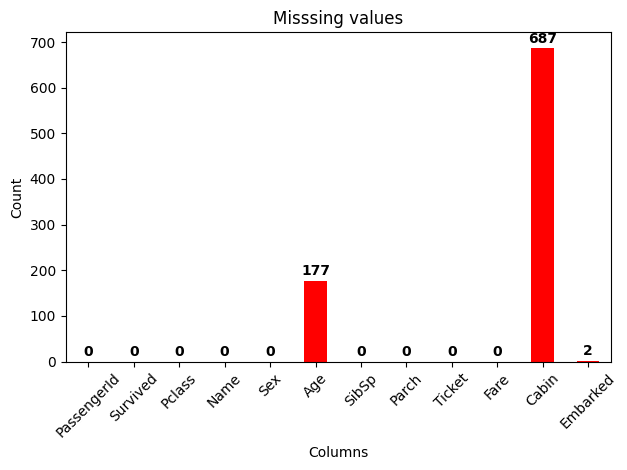

In [ ]:
miss=df.isnull().sum()
ax=miss.plot(kind="bar",color="red")
plt.title("Misssing values")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45)
for index,value in enumerate(miss):
    plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()    

In [12]:
df=df.drop(columns=['Cabin'])
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])


In [13]:
survived=df['Survived'].value_counts()
print(survived)

Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12780\3038478468.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=df,palette='pastel')


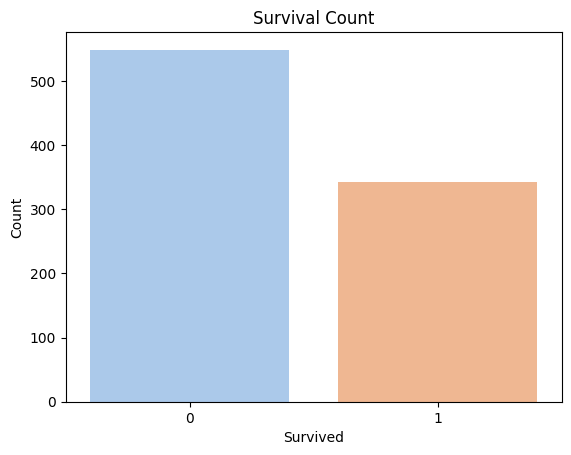

In [14]:
sns.countplot(x='Survived',data=df,palette='pastel')
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [15]:
gendercounts=df['Sex'].value_counts()
print(gendercounts)


Sex
male      577
female    314
Name: count, dtype: int64


In [17]:
survivalbygender=df.groupby(['Sex','Survived']).size()
print(survivalbygender)

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


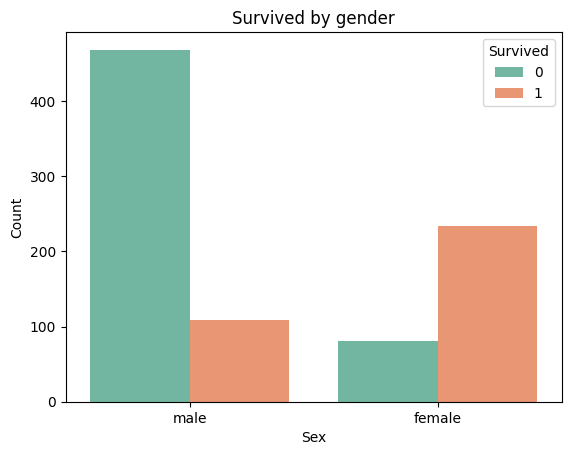

In [19]:
sns.countplot(x='Sex',data=df,hue='Survived',palette='Set2')
plt.title("Survived by gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title='Survived')
plt.show()

In [20]:
pclasscount=df['Pclass'].value_counts()
print(pclasscount)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


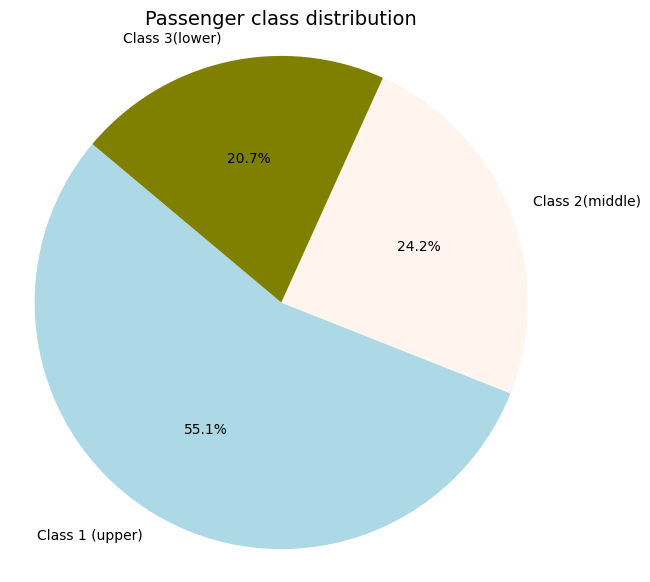

In [22]:
labels=['Class 1 (upper)','Class 2(middle)','Class 3(lower)']
plt.figure(figsize=(7,7))
plt.pie(pclasscount,labels=labels,autopct='%1.1f%%',startangle=140,colors=['lightblue','seashell','olive'])
plt.title("Passenger class distribution",fontsize=14)
plt.axis('equal')
plt.show()

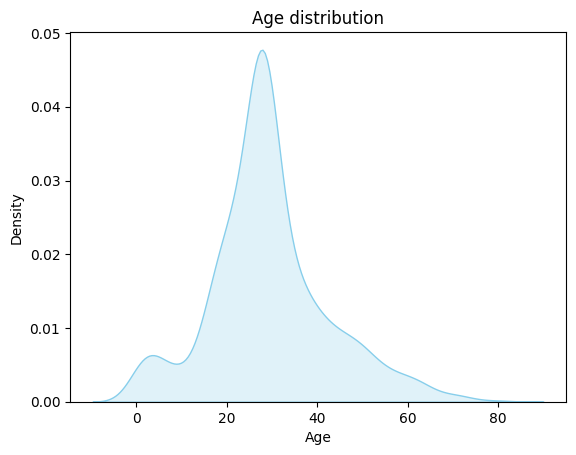

In [23]:
sns.kdeplot(df['Age'],fill=True,color='skyblue')
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

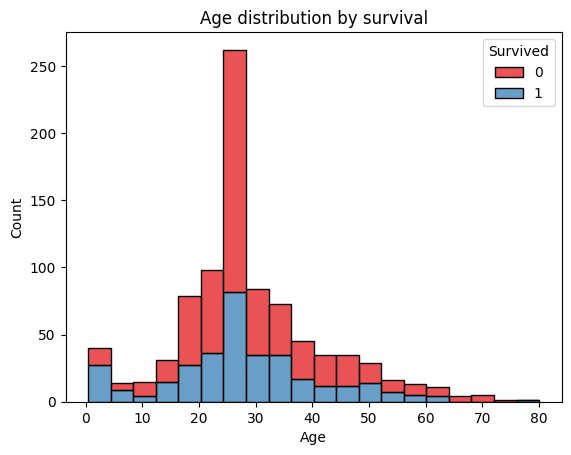

In [26]:
sns.histplot(data=df,x='Age',hue='Survived',multiple='stack',bins=20,palette='Set1')
plt.title("Age distribution by survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

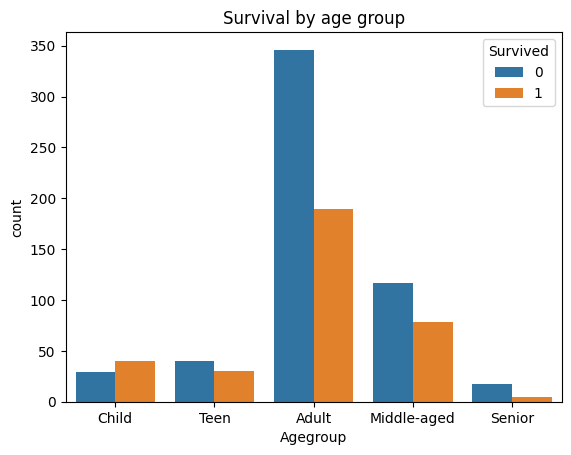

In [25]:
df['Agegroup']=pd.cut(df['Age'],bins=[0,12,18,35,60,80],labels=['Child','Teen','Adult','Middle-aged','Senior'])
sns.countplot(x='Agegroup',data=df,hue='Survived')
plt.title("Survival by age group")
plt.show()
              
              